In [2]:
! pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 18.8 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 74.6 MB/s  0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 85.0 MB/s  0:00:00

  Attempting uninstall: scikit-learn

    Found existing installation: scikit-learn 1.7.2

   ---------------------------------------- 0/3 [scikit-learn]
    Uninstalling scikit-learn-1.7.2:
   ---------------------------------------- 0/3 [scikit-learn]
      Successfully uninstalled scikit-learn-1.7.2
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   -----------

In [3]:
######################################### Import all the required libraries ###################################################
# Import libraries for df manipulation and statistics
import numpy as np
import pandas as pd
from scipy import stats

# Import libraries for df visualization
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline

# Import libraries for feature engineering and machine learning
import sklearn
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn import metrics
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Import other relevant libraries
import datetime
from datetime import date

# Silence warnings
import warnings
warnings.filterwarnings('ignore')

# Display all the columns in the pandas dfframe
pd.set_option("display.max_columns",None)

## Loading and Exploring Data

In [4]:
df = pd.read_csv('../data/raw/marketing_campaign.csv', sep='\t')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,11.984069,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,663,31-08-2012,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2240.0,NaN,NaN,NaN,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0


In [7]:
# Check if there are any missing values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [8]:
# Display the rows with missing values
df[df.isnull().any(axis=1)]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,5,6,0,2,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,1,3,3,263,362,0,27,0,0,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,11,50,3,2,39,1,1,3,4,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,5,48,6,10,7,3,2,1,4,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,3,22,2,2,6,2,2,0,3,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,3,43,17,4,17,3,3,0,3,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,42,192,49,37,53,12,7,2,8,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,0,8,2,0,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,37,359,98,28,18,1,2,4,8,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,0,27,10,0,15,3,6,1,7,6,0,0,0,0,0,0,3,11,0


In [9]:
# Check if there are any duplciates
df.duplicated().sum()

np.int64(0)

## Data Cleaning and Feature Engineering

### Remove redundant columns

In [10]:
df[['Z_CostContact','Z_Revenue']].nunique()

Z_CostContact    1
Z_Revenue        1
dtype: int64

In [11]:
# Remove the two columns with 1 unique value
df.drop(columns=['Z_CostContact','Z_Revenue'],inplace=True)

### Convert the data type of Dt_Customer to DateTime

In [12]:
df['Dt_Customer'] = pd.to_datetime(df.Dt_Customer, format="%d-%m-%Y")
df['Dt_Customer'].head()

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]

### Calculate the Tenure (Days as Customer) of each customer 

In [13]:
newest_date = df['Dt_Customer'].max()
newest_customers = df[df['Dt_Customer'] == newest_date]
newest_customers

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
200,7300,1952,Graduation,Divorced,69142.0,0,1,2014-06-29,50,448,4,34,6,4,39,3,8,1,7,5,0,1,0,0,0,0,0
989,453,1956,PhD,Widow,35340.0,1,1,2014-06-29,1,27,0,12,0,1,5,2,2,0,3,5,0,0,0,0,0,0,0


<br> The newest customers' maximum Recency is 50 days from their last purchase date. Let's assume that __NOW date (anchor_date = '2014-08-29')__ is 2 months (61 days) after their Dt_Customer date. 

In [14]:
anchor_date = newest_date + pd.DateOffset(days=61)
print (anchor_date)

2014-08-29 00:00:00


In [15]:
df['Tenure'] = (anchor_date - df['Dt_Customer']).dt.days
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,724
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,174
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,373
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,200
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,222


### Clean the invalid Age

In [16]:
# Calculate the Age of each customer from the Year_Birth and anchor_date
df['Age'] = 2014 - df['Year_Birth']

# Check if there are any invalid Age
df.query('Age > 100')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Tenure,Age
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,6,8,7,4,25,1,2,1,2,5,0,0,0,0,0,1,0,337,114
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,0,5,7,0,2,1,1,0,2,4,0,0,0,0,0,0,0,104,121
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,144,562,104,64,224,1,4,6,4,1,0,0,1,0,0,0,0,337,115


In [17]:
# Remove the rows with invalid Age
df = df[df.Age < 100]

### Handling outliers and missing values of Income

In [18]:
# Make a function to calculate Z-Score for outlier detection
def calc_z(df, col):
    mean = df[col].mean() 
    std = df[col].std()
    return (df[col]-mean)/std

(df
 .assign(Z_Score=calc_z(df, col='Income'))
 .query('Z_Score.abs() >= 3')
)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Tenure,Age,Z_Score
164,8475,1973,PhD,Married,157243.0,0,1,2014-03-01,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,0,0,0,0,0,181,41,4.170462
617,1503,1976,PhD,Together,162397.0,1,1,2013-06-03,31,85,1,16,2,1,2,0,0,0,1,1,0,0,0,0,0,0,0,452,38,4.375160
655,5555,1975,Graduation,Divorced,153924.0,0,0,2014-02-07,81,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,203,39,4.038644
687,1501,1982,PhD,Married,160803.0,0,0,2012-08-04,21,55,16,1622,17,3,4,15,0,28,1,0,0,0,0,0,0,0,0,755,32,4.311852
1300,5336,1971,Master,Together,157733.0,1,0,2013-06-04,37,39,1,9,2,0,8,0,1,0,1,1,0,0,0,0,0,0,0,451,43,4.189923
1653,4931,1977,Graduation,Together,157146.0,0,0,2013-04-29,13,1,0,1725,2,1,1,0,0,28,0,1,0,0,0,0,0,0,0,487,37,4.166610
2132,11181,1949,PhD,Married,156924.0,0,0,2013-08-29,85,2,1,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,365,65,4.157793
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,0,453,37,24.402840


Text(0.5, 1.0, 'Distrbution of Income')

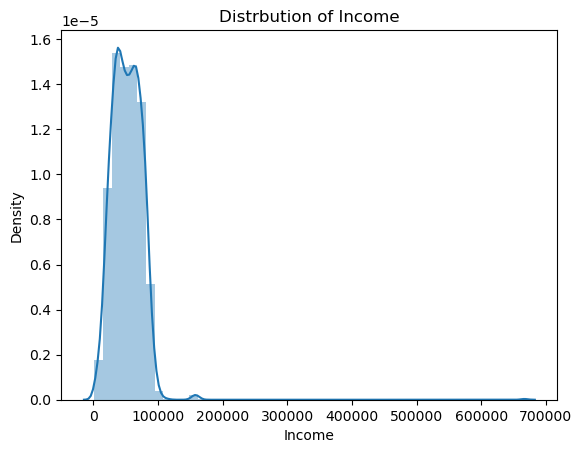

In [19]:
# Plot the distribution of Income
sns.distplot(df.Income)
plt.title('Distrbution of Income')

In [20]:
# Remove the extreme outlier (666666) to avoid skewness that could distort our analysis. 
df = df [df['Income']<600_000]

In [21]:
# Since missing values only account for about 1% of the data, remove null values. 
df = df.dropna(subset = ['Income'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2212 non-null   int64         
 1   Year_Birth           2212 non-null   int64         
 2   Education            2212 non-null   object        
 3   Marital_Status       2212 non-null   object        
 4   Income               2212 non-null   float64       
 5   Kidhome              2212 non-null   int64         
 6   Teenhome             2212 non-null   int64         
 7   Dt_Customer          2212 non-null   datetime64[ns]
 8   Recency              2212 non-null   int64         
 9   MntWines             2212 non-null   int64         
 10  MntFruits            2212 non-null   int64         
 11  MntMeatProducts      2212 non-null   int64         
 12  MntFishProducts      2212 non-null   int64         
 13  MntSweetProducts     2212 non-null   i

Text(0.5, 1.0, 'Distrbution of Cleaned Income')

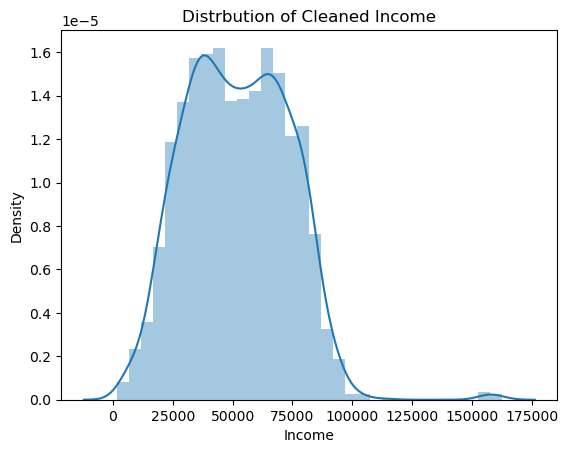

In [22]:
sns.distplot(df.Income)
plt.title('Distrbution of Cleaned Income')

### Segmenting Marital_Status and Education

In [23]:
# Remove all the leading and trailing spaces in columns names
df.columns = df.columns.str.strip()

In [24]:
# Segment 'Marital_Status' into two groups
df['Marital_Status'] = df['Marital_Status'].replace(['Married', 'Together'], 'Has_Partner')
df['Marital_Status'] = df['Marital_Status'].replace(['Divorced', 'Widow', 'Alone', 'YOLO', 'Absurd','Single'], 'Alone')


In [25]:
# Segment 'Education' into three groups
df['Education'] = df['Education'].replace({'Basic':'Undergraduate', '2n Cycle':'Undergraduate', 'Graduation':'Graduate', 'Master':'Postgraduate', 'PhD':'Postgraduate'})

### Feature Engineering

In [26]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Tenure,Age
0,5524,1957,Graduate,Alone,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,724,57
1,2174,1954,Graduate,Alone,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,174,60
2,4141,1965,Graduate,Has_Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,373,49
3,6182,1984,Graduate,Has_Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,200,30
4,5324,1981,Postgraduate,Has_Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,222,33


In [27]:
# Total spendings on all the products
df['Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# Total number of purchases on all the products
df['TotalNumPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'] + df['NumDealsPurchases']

# Total accepted compaign offers
df['AcceptedCmps'] = df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + df['AcceptedCmp4'] + df['AcceptedCmp5'] + df['Response']

# Total children living in the household
df['Children'] = df['Kidhome'] + df['Teenhome']

# Rename columns for clarity
df = df.rename(
    columns={'MntWines': 'Wines','MntFruits':'Fruits','MntMeatProducts':'Meat','MntFishProducts':'Fish','MntSweetProducts':'Sweets','MntGoldProds':'Gold'})

# Create a feature "Has_Child" to indicate parenthood status
df['Has_Child'] = np.where(df.Children > 0, 'Has_Child', 'No_Child')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2212 non-null   int64         
 1   Year_Birth           2212 non-null   int64         
 2   Education            2212 non-null   object        
 3   Marital_Status       2212 non-null   object        
 4   Income               2212 non-null   float64       
 5   Kidhome              2212 non-null   int64         
 6   Teenhome             2212 non-null   int64         
 7   Dt_Customer          2212 non-null   datetime64[ns]
 8   Recency              2212 non-null   int64         
 9   Wines                2212 non-null   int64         
 10  Fruits               2212 non-null   int64         
 11  Meat                 2212 non-null   int64         
 12  Fish                 2212 non-null   int64         
 13  Sweets               2212 non-null   i

In [29]:
cols_to_drop = ['Dt_Customer', 'Year_Birth']
df = df.drop(columns = cols_to_drop)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2212 non-null   int64  
 1   Education            2212 non-null   object 
 2   Marital_Status       2212 non-null   object 
 3   Income               2212 non-null   float64
 4   Kidhome              2212 non-null   int64  
 5   Teenhome             2212 non-null   int64  
 6   Recency              2212 non-null   int64  
 7   Wines                2212 non-null   int64  
 8   Fruits               2212 non-null   int64  
 9   Meat                 2212 non-null   int64  
 10  Fish                 2212 non-null   int64  
 11  Sweets               2212 non-null   int64  
 12  Gold                 2212 non-null   int64  
 13  NumDealsPurchases    2212 non-null   int64  
 14  NumWebPurchases      2212 non-null   int64  
 15  NumCatalogPurchases  2212 non-null   int64 

## Exploratory Data Analysis and Data Visualization

### Subsetting Data

In [30]:
all_cols = df.columns.to_list()

In [31]:
print (all_cols)

['ID', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Tenure', 'Age', 'Spending', 'TotalNumPurchases', 'AcceptedCmps', 'Children', 'Has_Child']


In [32]:
# Analyze the correlations among the three spending features
df[['Spending', 'TotalNumPurchases','Recency',]].corr(method='spearman').style .background_gradient(cmap='RdBu', vmin=-1, vmax=1)

,Spending,TotalNumPurchases,Recency
Spending,1.000000,0.865411,0.018907
TotalNumPurchases,0.865411,1.000000,0.011064
Recency,0.018907,0.011064,1.000000


In [33]:
# TotalNumPurchases and Spending are strongly correlated. To simplify the clustering analysis, we choose only one key feature, i.e. Spending.  
selected_cols1 = ['Income', 'Spending', 'Recency','Education', 'Marital_Status', 'Children', 'Age', 'Tenure', 'AcceptedCmps', 'NumWebVisitsMonth', 'Complain']

In [34]:
df1 = df[selected_cols1]

### Exploring the distribution of features

Text(0.5, 1.0, 'Distrbution of Spending')

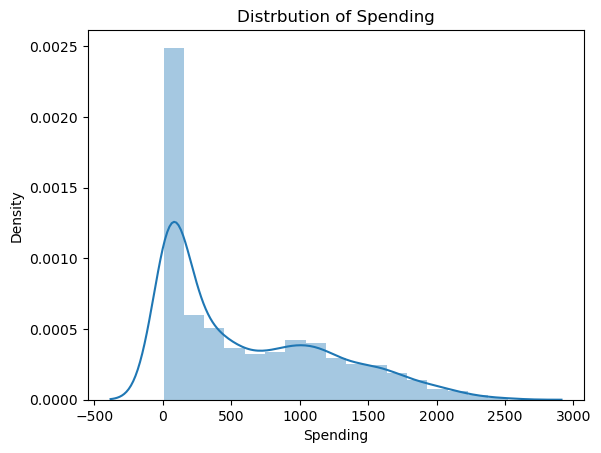

In [35]:
sns.distplot(df.Spending)
plt.title('Distrbution of Spending')

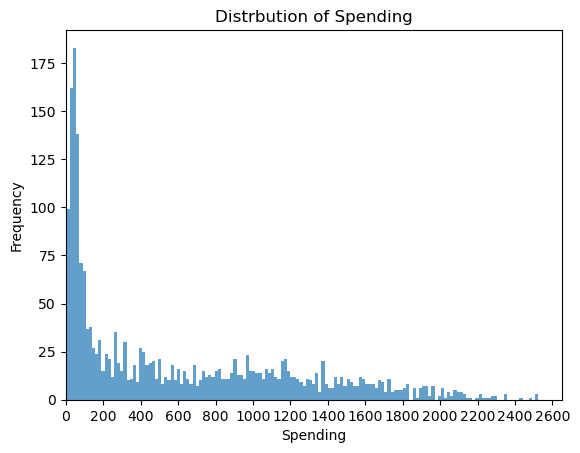

In [36]:
# Eavluate the distribution of Spending using histogram
plt.hist(df.Spending, bins=150,alpha = 0.7)
plt.xlabel('Spending')  # Label for x-axis
plt.ylabel('Frequency')  # Label for y-axis
plt.xticks(ticks=range(0, 2601, 200))  # Set x-axis ticks with interval of 200
plt.xlim(left=0)  # Set the minimum x-axis limit to 0
plt.title('Distrbution of Spending')
plt.show()

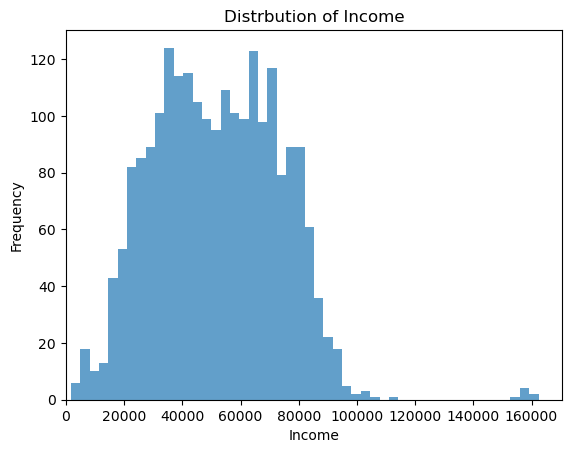

In [37]:
# Eavluate the distribution of Income using histogram
plt.hist(df.Income, bins=50,alpha=0.7)
plt.xlabel('Income')  # Label for x-axis
plt.ylabel('Frequency')  # Label for y-axis
plt.xticks(ticks=range(0, 170000, 20000))  # Set x-axis ticks with interval of 20000
plt.xlim(left=0)  # Set the minimum x-axis limit to 0
plt.title('Distrbution of Income')
plt.show()

### Correlation Analysis and Visualization

In [38]:
# Income and spending are continous numerical variables, but not normally distributed.
# Some features like Children and AcceptedCmps are multinomial categorical variables (ordinal variables), Age and Tenure are discrete variables.
# Therefore, we choose spearman correlation method.

(df1
 .corr(method='spearman', numeric_only=True)
 .style
 .background_gradient(cmap='RdBu', vmin=-1, vmax=1)
)

,Income,Spending,Recency,Children,Age,Tenure,AcceptedCmps,NumWebVisitsMonth,Complain
Income,1.000000,0.853119,0.009791,-0.375782,0.217604,-0.022710,0.311486,-0.643981,-0.027779
Spending,0.853119,1.000000,0.018907,-0.483948,0.159741,0.183186,0.385088,-0.476092,-0.037177
Recency,0.009791,0.018907,1.000000,0.012487,0.016514,0.025866,-0.104476,-0.019027,0.005786
Children,-0.375782,-0.483948,0.012487,1.000000,0.085111,-0.023099,-0.240189,0.430880,0.030610
Age,0.217604,0.159741,0.016514,0.085111,1.000000,-0.013528,0.022275,-0.132433,0.000890
Tenure,-0.022710,0.183186,0.025866,-0.023099,-0.013528,1.000000,0.085236,0.304545,0.036186
AcceptedCmps,0.311486,0.385088,-0.104476,-0.240189,0.022275,0.085236,1.000000,-0.074742,-0.023673
NumWebVisitsMonth,-0.643981,-0.476092,-0.019027,0.430880,-0.132433,0.304545,-0.074742,1.000000,0.026497
Complain,-0.027779,-0.037177,0.005786,0.030610,0.000890,0.036186,-0.023673,0.026497,1.000000


## Clustering Analysis

### KMeans Clustering

### Elbow Method to determine the optimal number of clusters

In [39]:
# Subsetting data
# Select the three most important numerical features for clustering analysis
df_temp = df[['Income', 'Spending', 'Children']]

In [40]:
# Scale data
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df_temp)
scaled_df = pd.DataFrame(scaled_df, columns=df_temp.columns)

In [41]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)  # Set to display 3 decimal places

scaled_df.head()

,Income,Spending,Children
0,0.287,1.676,-1.265
1,-0.261,-0.963,1.405
2,0.913,0.280,-1.265
3,-1.176,-0.920,0.070
4,0.294,-0.308,0.070


### Elbow Plot for KMeans Clustering

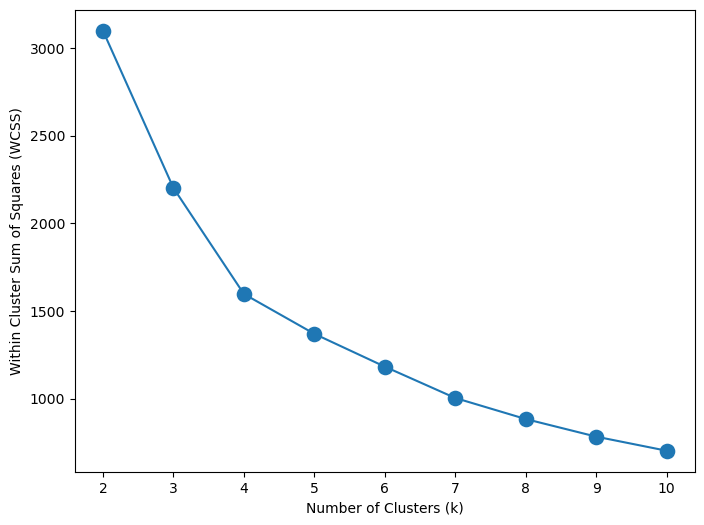

In [42]:
# Set up a random_state (5) to get consistent result
# Create the elbow plot
wcss = []
for k in range(2, 11):
    km = KMeans(n_clusters = k, n_init = 25, random_state = 5)
    km.fit(scaled_df)
    wcss.append(km.inertia_)

wcss_series = pd.Series(wcss, index = range(2, 11))

plt.figure(figsize=(8, 6))
ax = sns.lineplot(y = wcss_series, x = wcss_series.index)
ax = sns.scatterplot(y = wcss_series, x = wcss_series.index, s = 150)
ax = ax.set(xlabel = 'Number of Clusters (k)', 
            ylabel = 'Within Cluster Sum of Squares (WCSS)')

The elbow plot indicates that __the optimal number of clusters is 4__. 

#### Perform K-means clustering

In [43]:
clusters = KMeans(n_clusters=4, random_state=5).fit(scaled_df)

In [44]:
scaled_df['Cluster'] = clusters.labels_
scaled_df.head(10)

,Income,Spending,Children,Cluster
0,0.287,1.676,-1.265,0
1,-0.261,-0.963,1.405,3
2,0.913,0.280,-1.265,0
3,-1.176,-0.920,0.070,1
4,0.294,-0.308,0.070,2
5,0.490,0.181,0.070,2
6,0.171,-0.029,0.070,2
7,-0.860,-0.728,0.070,1
8,-1.004,-0.932,0.070,1
9,-2.152,-0.927,1.405,3


In [45]:
df_temp['Cluster'] = clusters.labels_
df_temp = df_temp.replace({0:'Stars', 1:'Leaky bucket', 2:'High potential', 3:'Need attention'})
df = df.merge(df_temp.Cluster, left_index=True, right_index=True)
pd.options.display.float_format = "{:.0f}".format
summary = df[['Income','Spending','Children','Cluster']]
summary.set_index("Cluster", inplace = True)
summary = summary.groupby('Cluster').describe().transpose()
# summary=summary.groupby('Cluster').describe()
summary

Cluster         High potential  Leaky bucket  Need attention  Stars
Income   count             511           773             428    500
         mean            63725         32829           42168  77889
         std              9583         11514           12086  12838
         min             42564          1730            4023  44802
         25%             57478         24072           34787  70612
         50%             62845         33051           42308  77766
         75%             69139         41769           50743  82632
         max            162397         59892           75283 160803
Spending count             511           773             428    500
         mean              859           144             177   1435
         std               336           156             202    423
         min               107             5               8      6
         25%               600            43              43   1129
         50%               860            76              80   1428
         75%              1087           199             261   1725
         max              1750          1730            1314   2525
Children count             511           773             428    500
         mean                1             1               2      0
         std                 0             0               0      0
         min                 0             0               2      0
         25%                 1             1               2      0
         50%                 1             1               2      0
         75%                 1             1               2      0
         max                 3             1               3      1

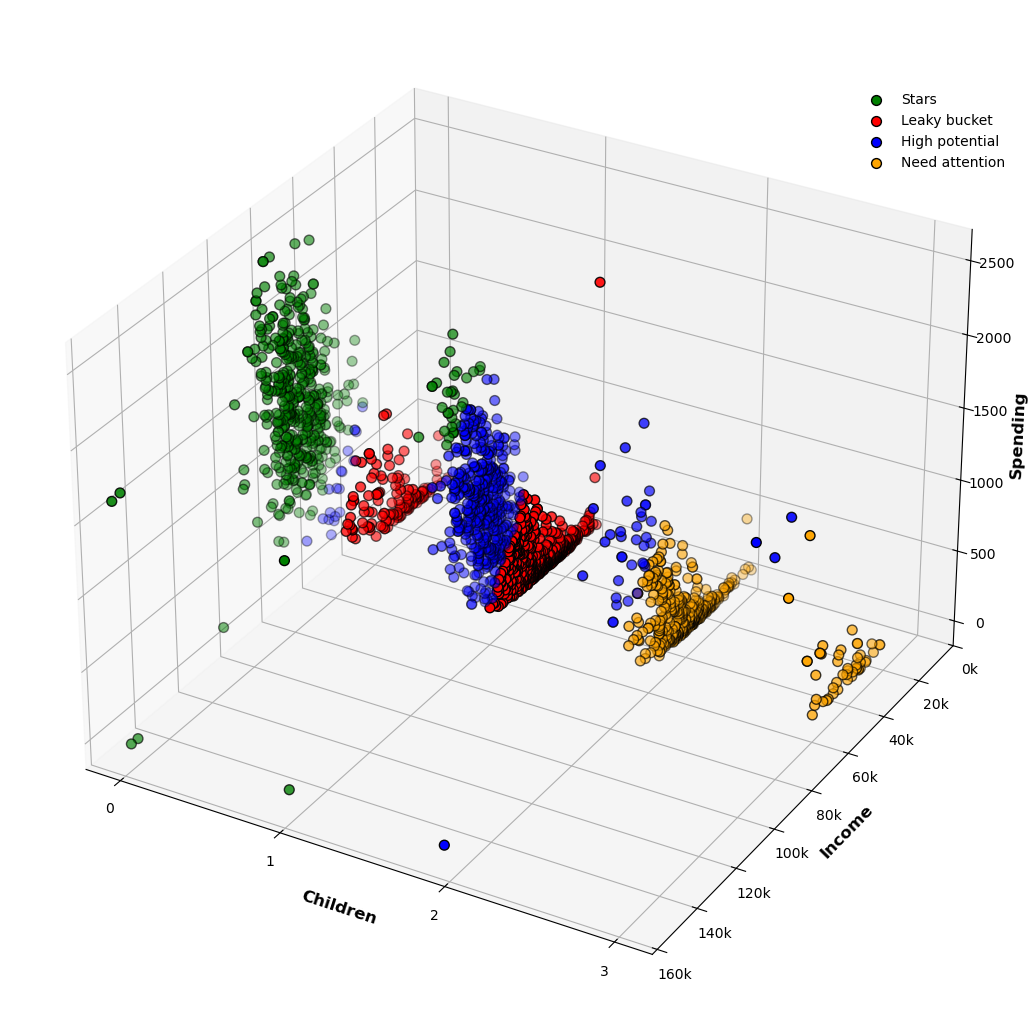

In [46]:
# Define the variables for the 3D clusters plot
data = {'Income': df['Income'],
        'Children': df['Children'],
        'Spending': df['Spending'],
        'Cluster': df['Cluster']}
df_plot = pd.DataFrame(data)

# Define custom colors for the clusters
cluster_colors = {
    'Stars': 'green',
    'Leaky bucket': 'red',
    'High potential': 'blue',
    'Need attention': 'orange'
}

# Create the 3D scatter plot
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

# Loop over each unique cluster
for cluster, color in cluster_colors.items():
    subset = df_plot[df_plot['Cluster'] == cluster]
    ax.scatter(subset['Children'], subset['Income'], subset['Spending'], 
               s=50, color=color, label=cluster, edgecolors='k')

# Set axis labels and tick parameters
ax.set_xlabel('Children', color='black', fontsize=12, fontweight='bold')
ax.set_ylabel('Income', color='black', fontsize=12, fontweight='bold')
ax.set_zlabel('Spending', color='black', fontsize=12, fontweight='bold')

# Set the tick labels for Children axis 
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0', '1', '2', '3'])

# Display the Income units in thousands
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# Set custom y-ticks to include 0
y_ticks = [0] + list(range(20000, int(df['Income'].max()) + 1, 20000))
ax.set_yticks(y_ticks)

# Reverse the Income axis by setting the limits in reverse order
ax.set_ylim(df['Income'].max(), 0)

# Add legend at the upper right corner
ax.legend()

# Position legend closer to the top left of the plot
ax.legend(loc='upper right', bbox_to_anchor=(1, 0.93), frameon=False)

# Use tight layout to minimize truncation issues
plt.tight_layout()
fig.subplots_adjust(left=0.14, right=0.86, bottom=0.1, top=0.9)

# Show the plot
plt.show()

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2212 non-null   int64  
 1   Education            2212 non-null   object 
 2   Marital_Status       2212 non-null   object 
 3   Income               2212 non-null   float64
 4   Kidhome              2212 non-null   int64  
 5   Teenhome             2212 non-null   int64  
 6   Recency              2212 non-null   int64  
 7   Wines                2212 non-null   int64  
 8   Fruits               2212 non-null   int64  
 9   Meat                 2212 non-null   int64  
 10  Fish                 2212 non-null   int64  
 11  Sweets               2212 non-null   int64  
 12  Gold                 2212 non-null   int64  
 13  NumDealsPurchases    2212 non-null   int64  
 14  NumWebPurchases      2212 non-null   int64  
 15  NumCatalogPurchases  2212 non-null   int64 

In [48]:
df.head()

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Tenure,Age,Spending,TotalNumPurchases,AcceptedCmps,Children,Has_Child,Cluster
0,5524,Graduate,Alone,58138,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,724,57,1617,25,1,0,No_Child,Stars
1,2174,Graduate,Alone,46344,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,174,60,27,6,0,2,Has_Child,Need attention
2,4141,Graduate,Has_Partner,71613,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,373,49,776,21,0,0,No_Child,Stars
3,6182,Graduate,Has_Partner,26646,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,200,30,53,8,0,1,Has_Child,Leaky bucket
4,5324,Postgraduate,Has_Partner,58293,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,222,33,422,19,0,1,Has_Child,High potential


## Data Transformation for Customer Personality Analysis

In [49]:
#Create Age segment (Binning)
cut_labels_Age = ['Young', 'Adult', 'Mature', 'Senior']
cut_bins = [0, 30, 45, 65, 100]
df['Age_Group'] = pd.cut(df['Age'], bins=cut_bins, labels=cut_labels_Age)

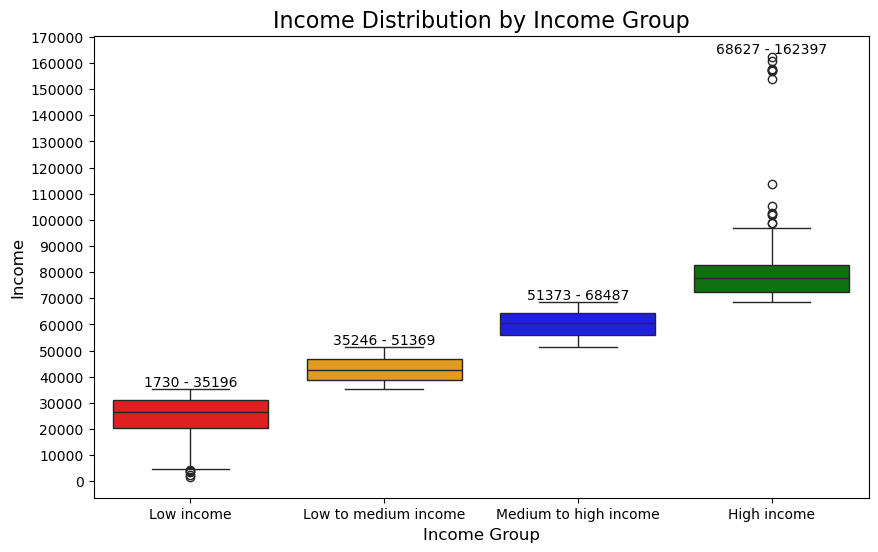

In [50]:
#Create Income segment
cut_labels_Income = ['Low income', 'Low to medium income', 'Medium to high income', 'High income']
df['Income_Group'] = pd.qcut(df['Income'], q=4, labels=cut_labels_Income)

# Group by 'Income_Group' and calculate the min and max income for each group
grouped = df.groupby('Income_Group')['Income'].agg(['min', 'max']).reset_index()

# Define a custom color palette
custom_palette = {
    'Low income': 'red',
    'Low to medium income': 'orange',
    'Medium to high income': 'blue',
    'High income': 'green'
}

# Plot the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Income_Group', y='Income', data=df, palette=custom_palette)

# Add range annotations for each group
for i in range(grouped.shape[0]):
    min_income = int(grouped['min'].iloc[i])
    max_income = int(grouped['max'].iloc[i])
    
    # Place text annotations above the boxplot for each group
    plt.text(i, max_income, f"{min_income} - {max_income}", 
             ha='center', va='bottom', fontsize=10, color='black')

# Set title and labels
plt.title('Income Distribution by Income Group', fontsize=16)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Income', fontsize=12)

# Set y-axis ticks with intervals of 10,000
y_min, y_max = plt.ylim()  # Get current y-axis limits
plt.yticks(np.arange(0, y_max, 10000))  # Set custom ticks with a step of 10,000

# Display the plot
plt.show()

In [51]:
#Create Tenure segment
cut_labels_Tenure = ['New customers', 'Discovering customers', 'Experienced customers', 'Old customers']
df['Tenure_Group'] = pd.qcut(df['Tenure'], q=4, labels=cut_labels_Tenure)

In [52]:
# Create consumption segments for different products
cut_labels = ['Low consumer', 'Moderate consumer', 'High consumer']
df['Wines_Segment'] = pd.qcut(df['Wines'][df['Wines']>0],q=[0, .25, .75, 1], labels=cut_labels).astype("object")
df['Fruits_Segment'] = pd.qcut(df['Fruits'][df['Fruits']>0],q=[0, .25, .75, 1], labels=cut_labels).astype("object")
df['Meat_Segment'] = pd.qcut(df['Meat'][df['Meat']>0],q=[0, .25, .75, 1], labels=cut_labels).astype("object")
df['Fish_Segment'] = pd.qcut(df['Fish'][df['Fish']>0],q=[0, .25, .75, 1], labels=cut_labels).astype("object")
df['Sweets_Segment'] = pd.qcut(df['Sweets'][df['Sweets']>0],q=[0, .25, .75, 1], labels=cut_labels).astype("object")
df['Gold_Segment'] = pd.qcut(df['Gold'][df['Gold']>0],q=[0, .25, .75, 1], labels=cut_labels).astype("object")
df.replace(np.nan, "Non consumer",inplace=True)
# Keep a copy of the dataframe which includes all the original data
df_copy = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ID                   2212 non-null   int64   
 1   Education            2212 non-null   object  
 2   Marital_Status       2212 non-null   object  
 3   Income               2212 non-null   float64 
 4   Kidhome              2212 non-null   int64   
 5   Teenhome             2212 non-null   int64   
 6   Recency              2212 non-null   int64   
 7   Wines                2212 non-null   int64   
 8   Fruits               2212 non-null   int64   
 9   Meat                 2212 non-null   int64   
 10  Fish                 2212 non-null   int64   
 11  Sweets               2212 non-null   int64   
 12  Gold                 2212 non-null   int64   
 13  NumDealsPurchases    2212 non-null   int64   
 14  NumWebPurchases      2212 non-null   int64   
 15  NumCatalogPurchases  2212 

In [53]:
df.drop(columns=['Spending','Wines','Fruits','Meat','Fish','Sweets','Gold','Age','Income','Tenure'],inplace=True)
df = df.astype(object)

In [54]:
# Select the relevant columns for association rules 
df = df [['Cluster', 'Education', 'Marital_Status','Children', 'Age_Group', 'Income_Group','Tenure_Group','Wines_Segment', 'Fruits_Segment', 'Meat_Segment', 'Fish_Segment',  'Sweets_Segment',  'Gold_Segment']]

## Customer Personality Analysis using Apriori Algorithm

In [55]:
# Set display options for wider outputs
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 999)
pd.options.display.float_format = "{:.3f}".format

# Create a copy of the association DataFrame
association = df.copy() 
df = pd.get_dummies(association)

# Parameters for apriori
min_support = 0.08
max_len = 10

# Generate frequent itemsets
frequent_items = apriori(df, use_colnames=True, min_support=min_support, max_len=max_len + 1)

# Generate association rules
rules = association_rules(frequent_items, metric='lift', min_threshold=1)

# List of products to analyze
products = [ 'Meat', 'Wines','Fruits', 'Fish','Sweets', 'Gold']
segment = 'High consumer'

# Initialize an empty DataFrame to store consolidated results
consolidated_results = pd.DataFrame()

# Loop through each product and store the top 5 results in the DataFrame
for product in products:
    target = '{\'%s_Segment_%s\'}' % (product, segment)
    results = rules[rules['consequents'].astype(str).str.contains(target, na=False)].sort_values(by='confidence', ascending=False).head()
    
    # Add a column to specify which product the rules apply to
    results['Product'] = product
    
    # Append results to the consolidated DataFrame
    consolidated_results = pd.concat([consolidated_results, results])

# Reset index of the consolidated DataFrame
consolidated_results.reset_index(drop=True, inplace=True)

# Display the consolidated DataFrame
consolidated_results

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,Product
0,"(Children_0, Fish_Segment_High consumer, Income_Group_High income)",(Meat_Segment_High consumer),0.102,0.250,0.092,0.903,3.611,1.000,0.067,7.705,0.805,0.355,0.870,0.636,Meat
1,"(Children_0, Cluster_Stars, Fish_Segment_High consumer, Income_Group_High income)",(Meat_Segment_High consumer),0.102,0.250,0.092,0.903,3.611,1.000,0.067,7.705,0.805,0.355,0.870,0.636,Meat
2,"(Cluster_Stars, Fish_Segment_High consumer, Income_Group_High income)",(Meat_Segment_High consumer),0.111,0.250,0.100,0.902,3.610,1.000,0.073,7.688,0.813,0.385,0.870,0.652,Meat
3,"(Cluster_Stars, Fish_Segment_High consumer)",(Meat_Segment_High consumer),0.131,0.250,0.118,0.897,3.586,1.000,0.085,7.250,0.830,0.446,0.862,0.683,Meat
4,"(Children_0, Cluster_Stars, Fish_Segment_High consumer)",(Meat_Segment_High consumer),0.122,0.250,0.109,0.896,3.585,1.000,0.079,7.232,0.821,0.417,0.862,0.667,Meat
5,"(Meat_Segment_High consumer, Cluster_Stars, Income_Group_High income)",(Wines_Segment_High consumer),0.162,0.249,0.103,0.635,2.554,1.000,0.063,2.059,0.726,0.335,0.514,0.525,Wines
6,"(Meat_Segment_High consumer, Income_Group_High income)",(Wines_Segment_High consumer),0.189,0.249,0.118,0.625,2.515,1.000,0.071,2.005,0.743,0.371,0.501,0.551,Wines
7,"(Marital_Status_Has_Partner, Cluster_Stars)",(Wines_Segment_High consumer),0.138,0.249,0.086,0.624,2.510,1.000,0.052,1.999,0.698,0.287,0.500,0.486,Wines
8,"(Cluster_Stars, Income_Group_High income)",(Wines_Segment_High consumer),0.187,0.249,0.117,0.623,2.506,1.000,0.070,1.994,0.739,0.365,0.498,0.546,Wines
9,"(Meat_Segment_High consumer, Cluster_Stars)",(Wines_Segment_High consumer),0.190,0.249,0.118,0.622,2.503,1.000,0.071,1.989,0.742,0.370,0.497,0.549,Wines


## Clusters Analysis and Customers Profiling

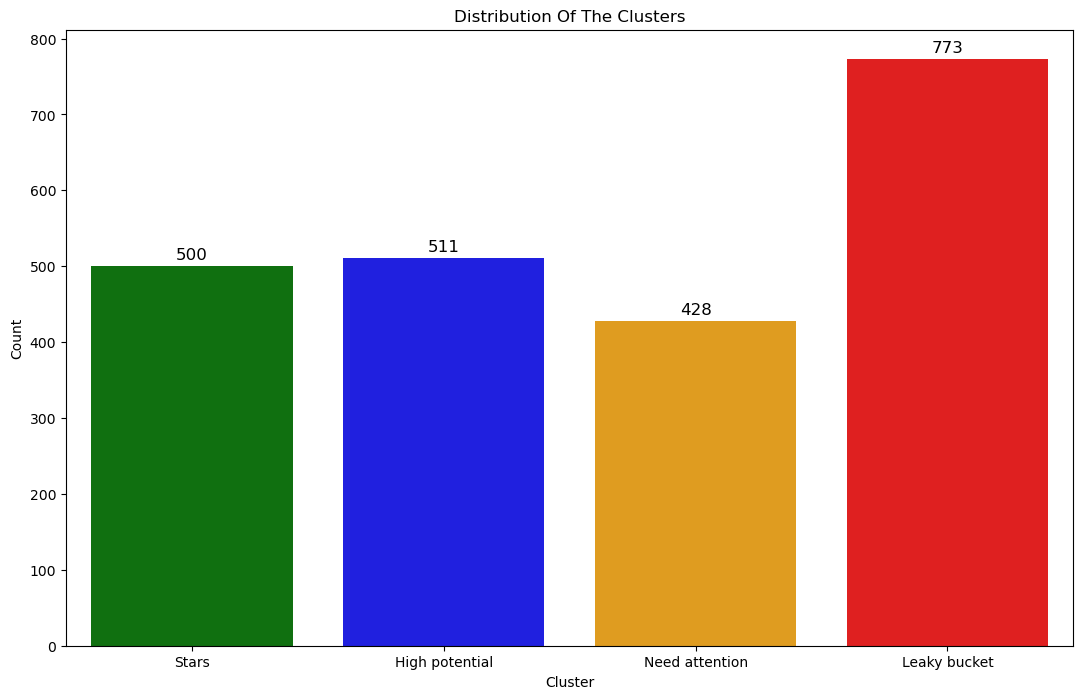

In [56]:
# Create a copy of the original DataFrame and add a new column 'Cluster' 
df_clusters = df_copy

# Plot the distribution of the clusters
custom_palette = {'Stars':'green', 'Leaky bucket':'red', 'High potential':'blue', 'Need attention':'orange'}
plt.figure(figsize=(13,8))
ax = sns.countplot(x=df_clusters['Cluster'], order=['Stars','High potential','Need attention','Leaky bucket'], palette=custom_palette)
# Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')
plt.title('Distribution Of The Clusters')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

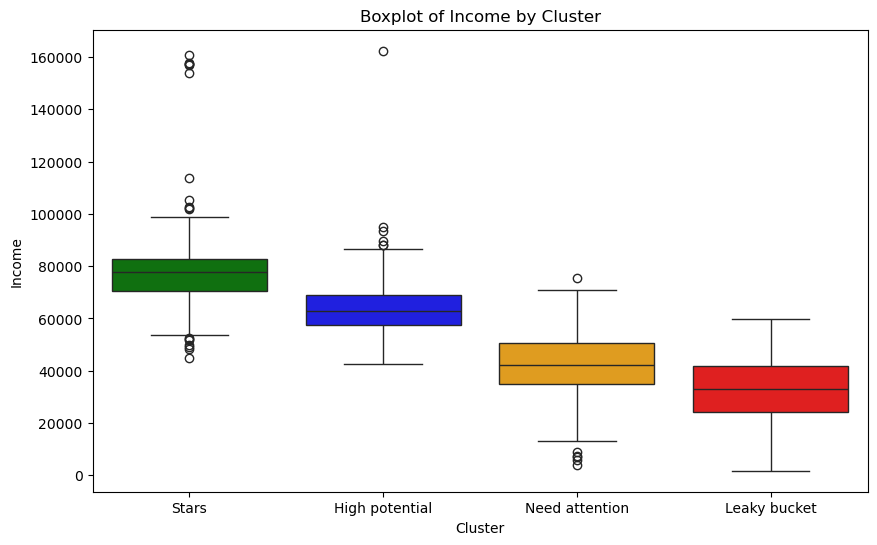

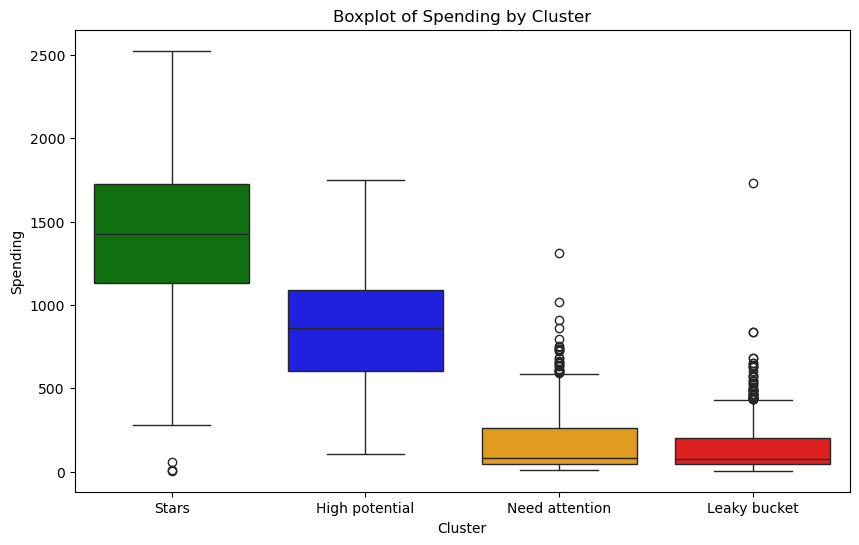

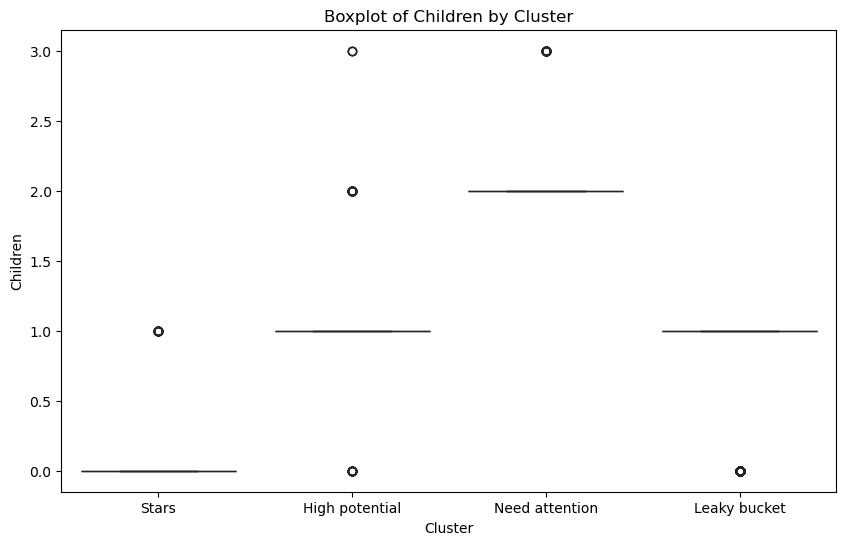

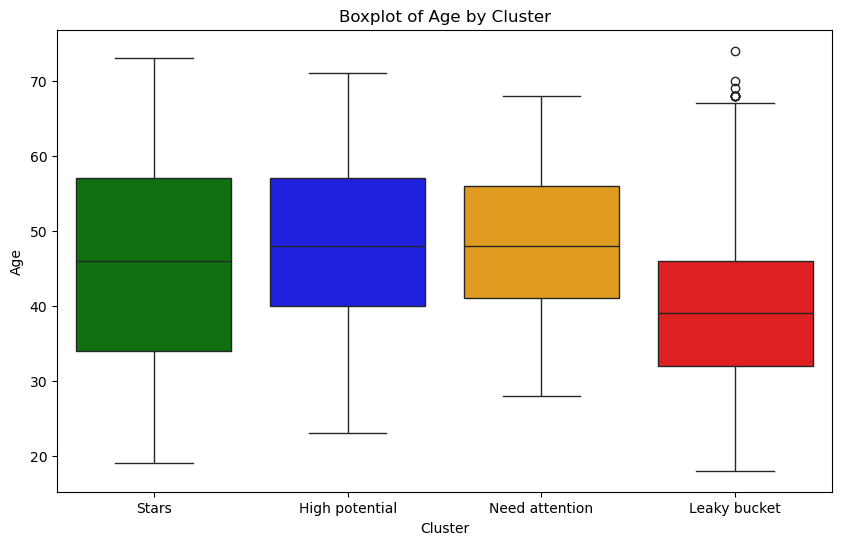

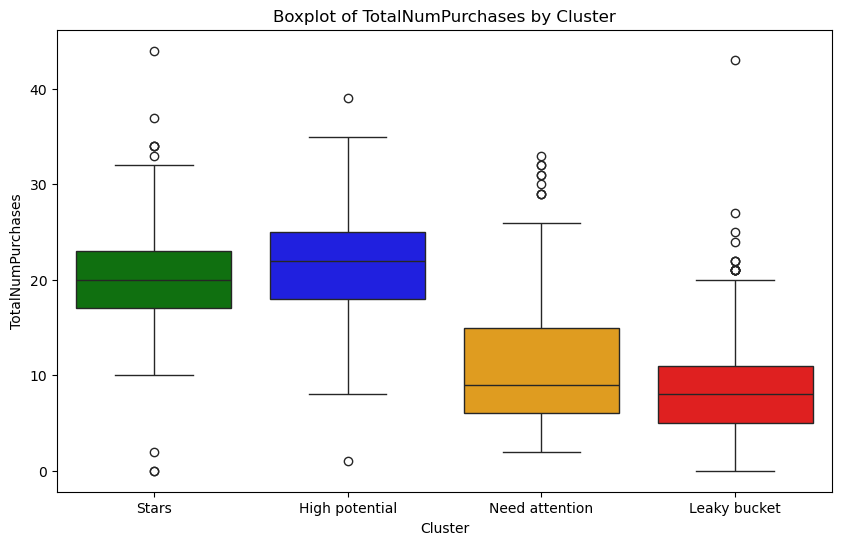

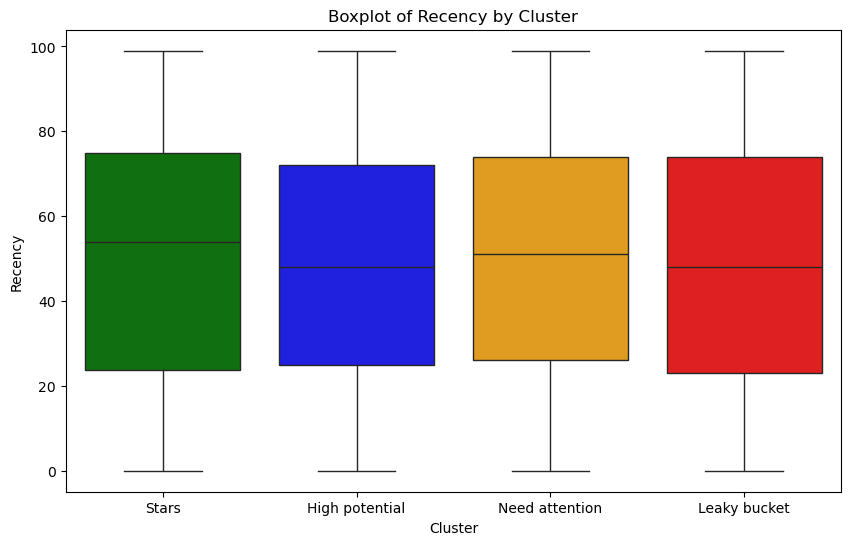

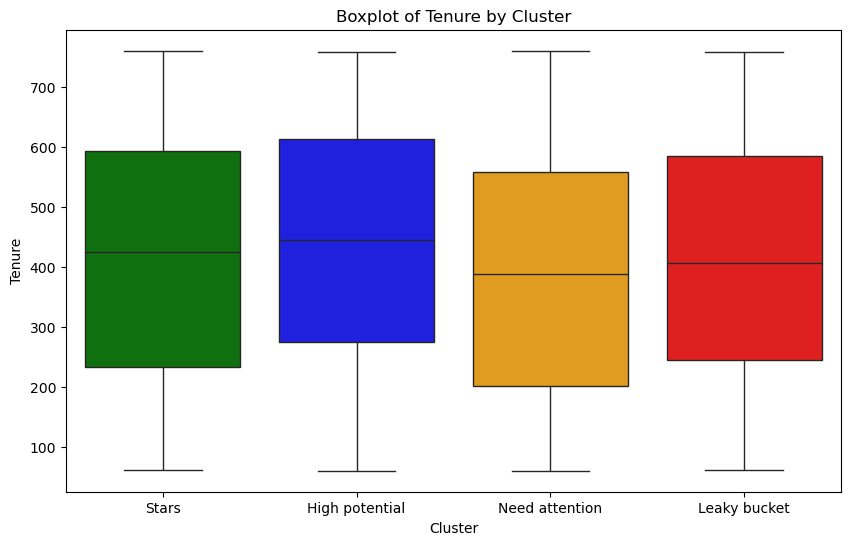

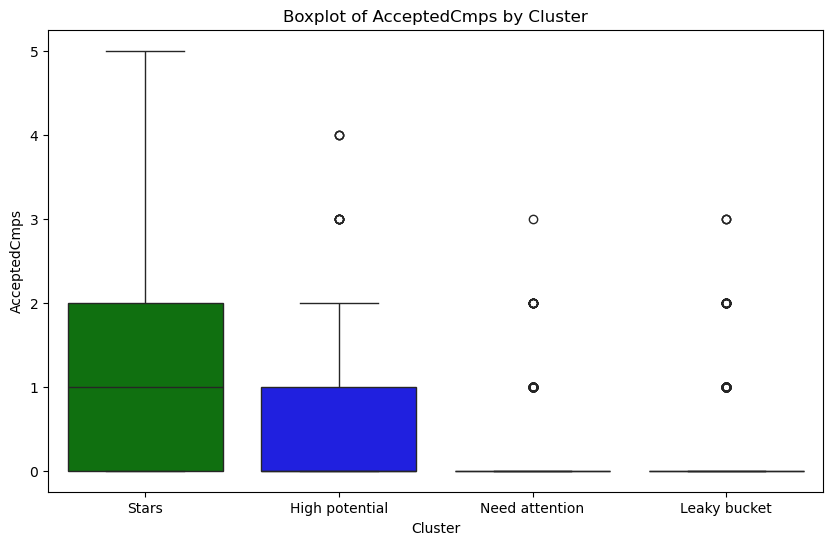

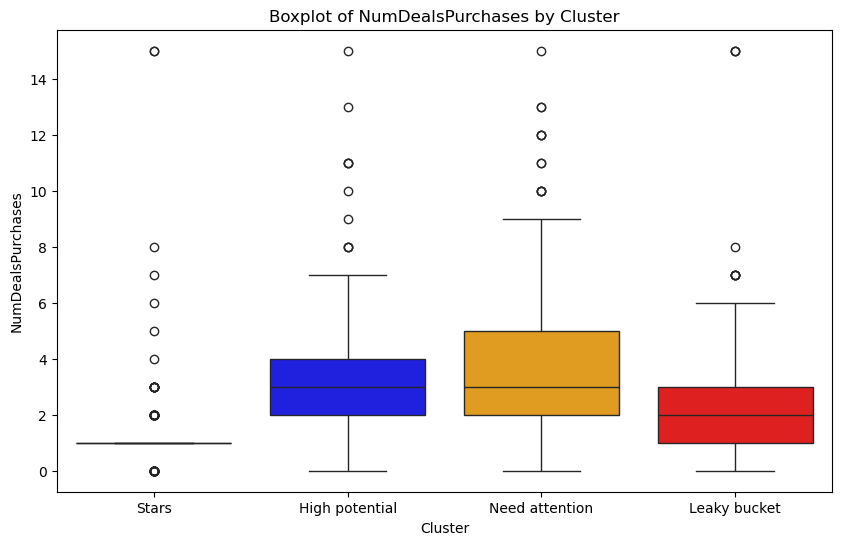

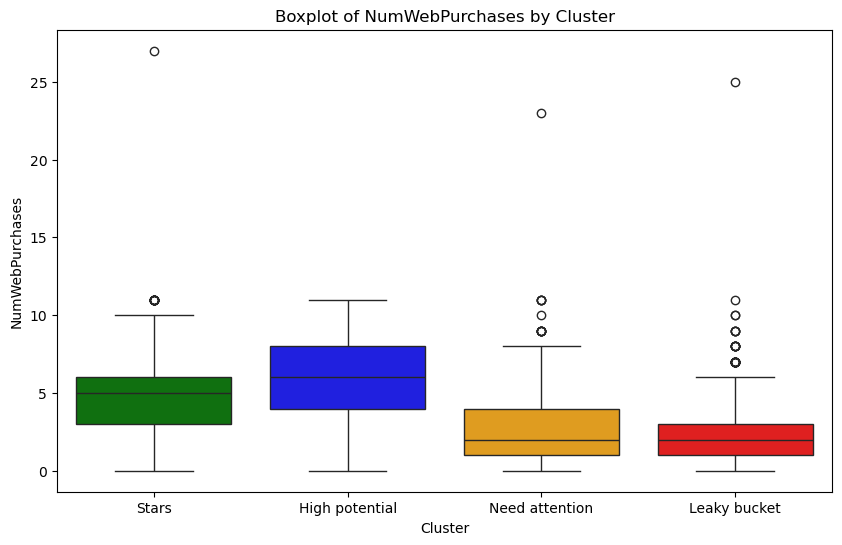

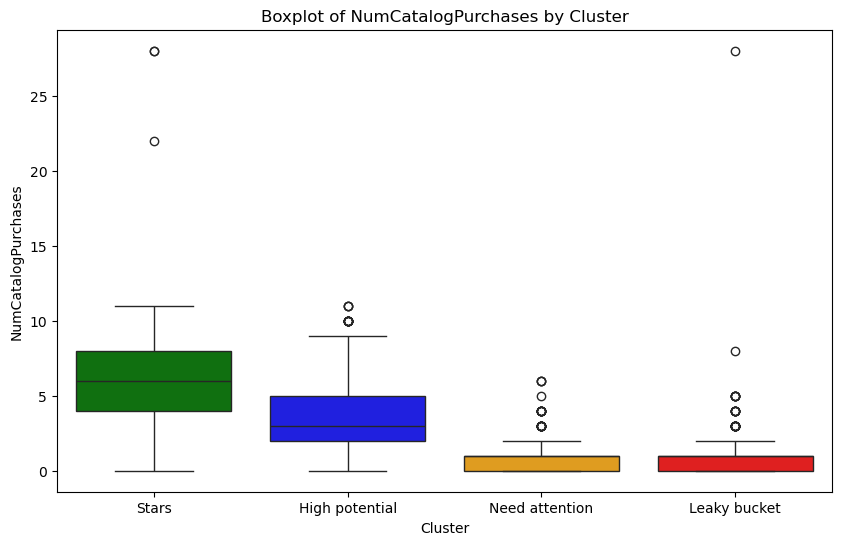

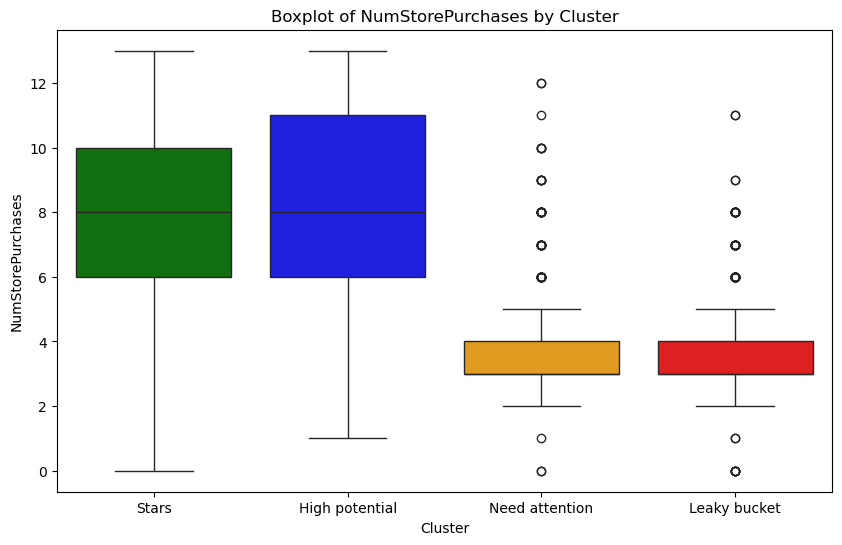

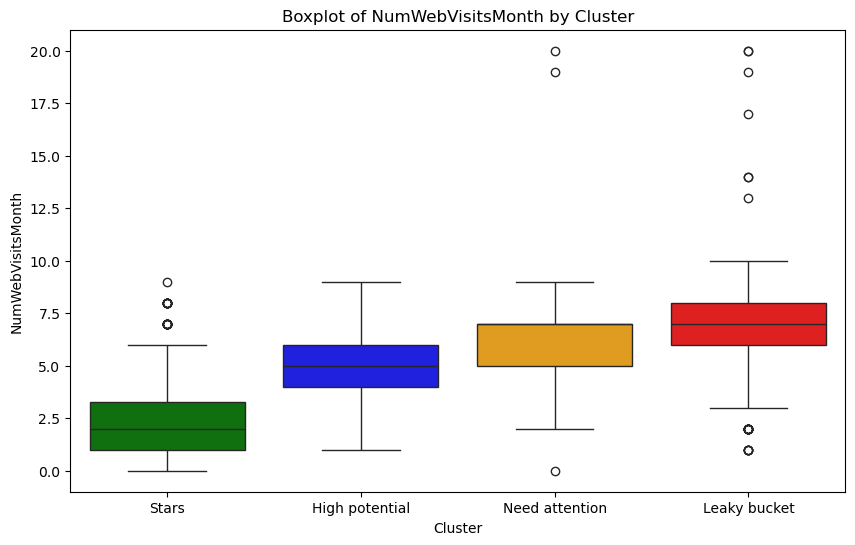

In [57]:
# Select numerical columns to plot
columns_to_plot = ['Income', 'Spending', 'Children', 'Age', 'TotalNumPurchases', 'Recency', 'Tenure', 'AcceptedCmps','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth'] 

custom_palette = {'Stars':'green', 'Leaky bucket':'red', 'High potential':'blue', 'Need attention':'orange'}

# Plot boxplots for each numerical column
for column in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cluster', y=column, data=df_clusters, order=['Stars','High potential','Need attention','Leaky bucket'], palette=custom_palette)  # Adjust palette as needed
    plt.title(f'Boxplot of {column} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(column)
    plt.show()

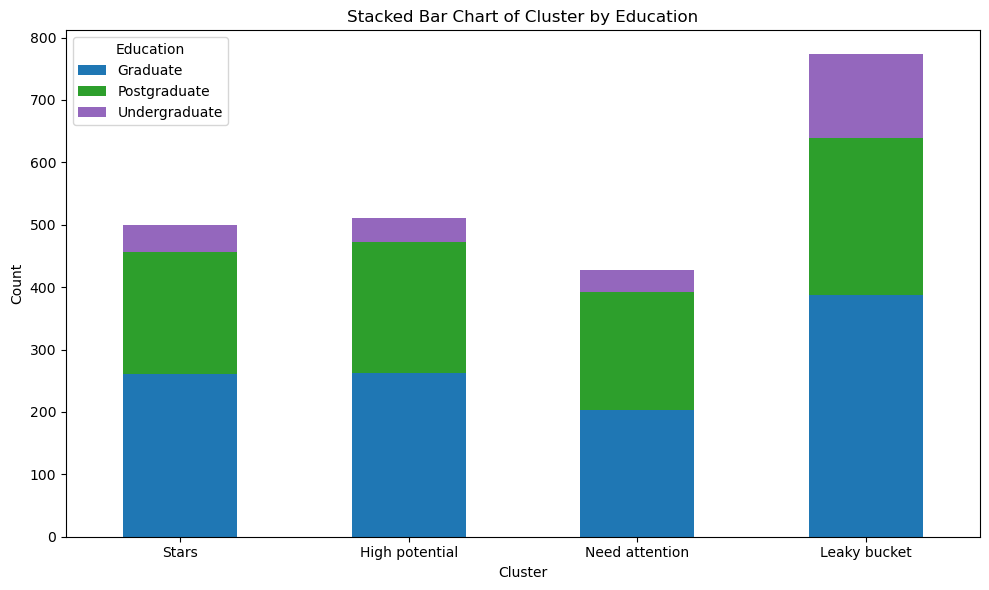

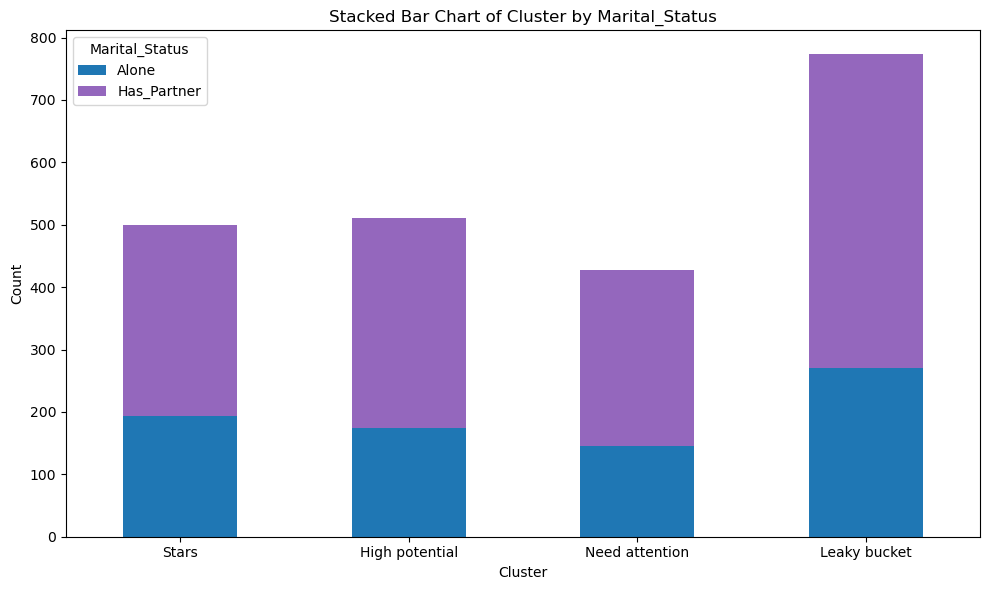

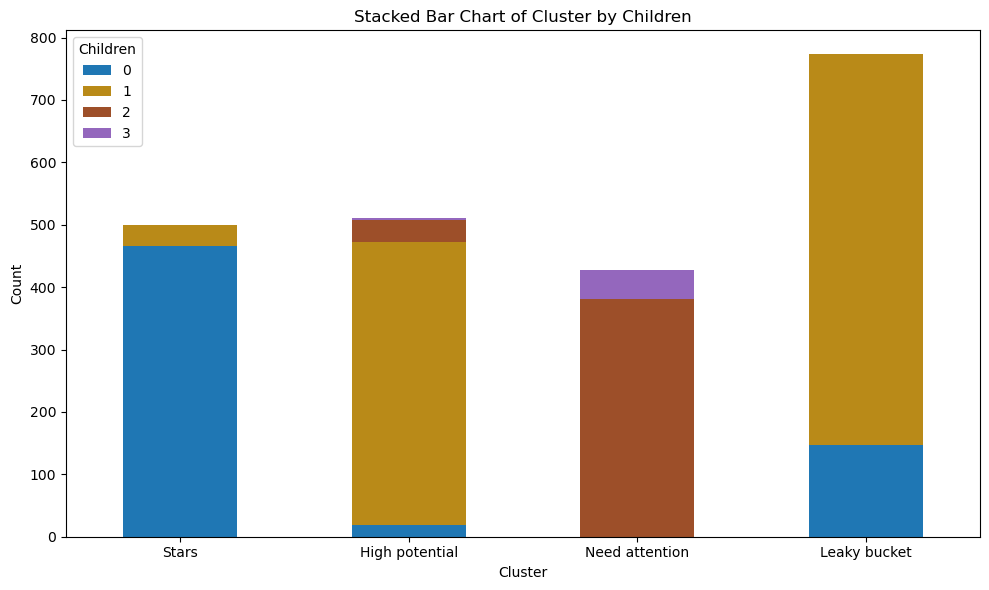

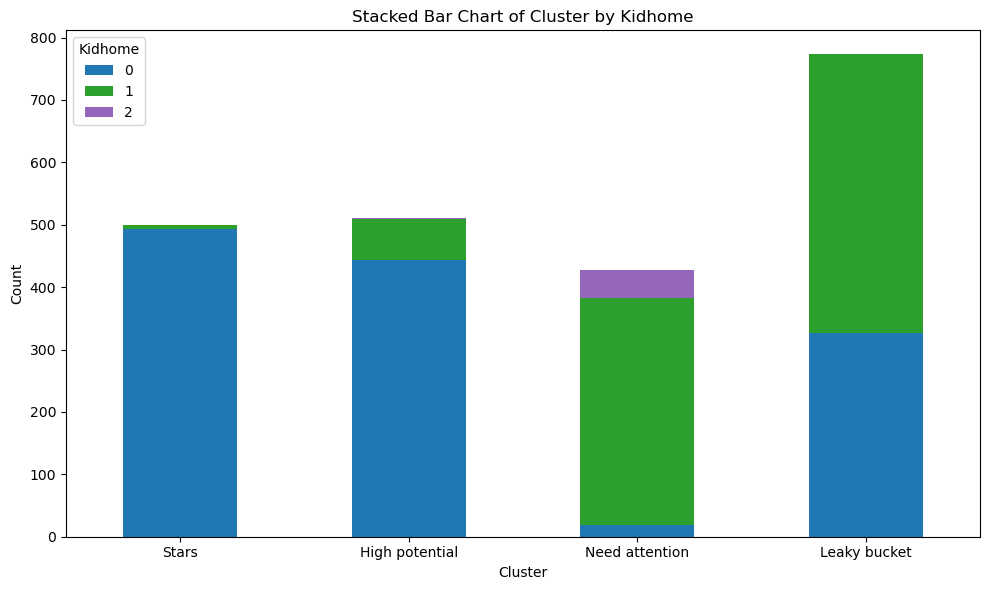

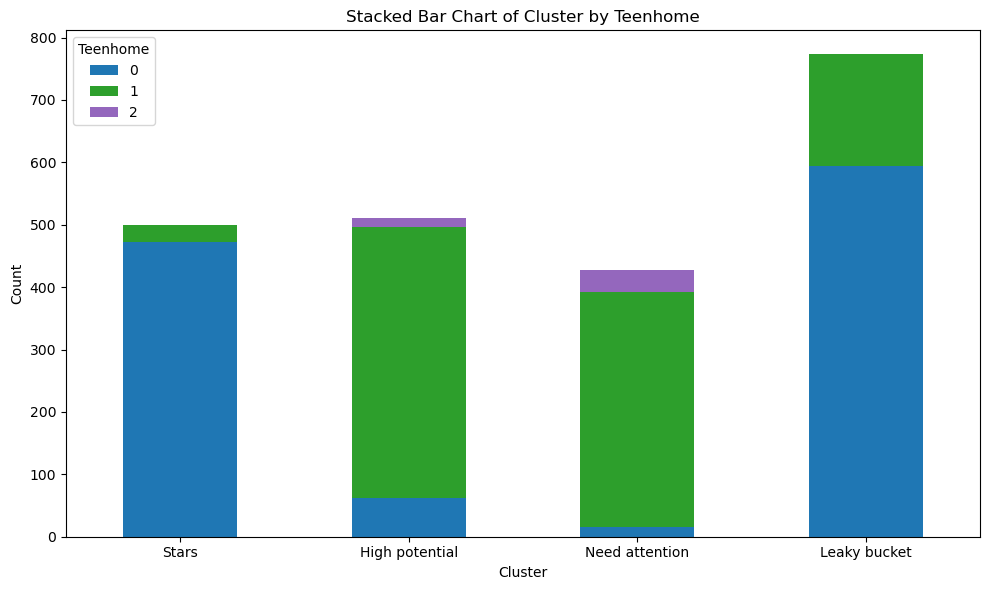

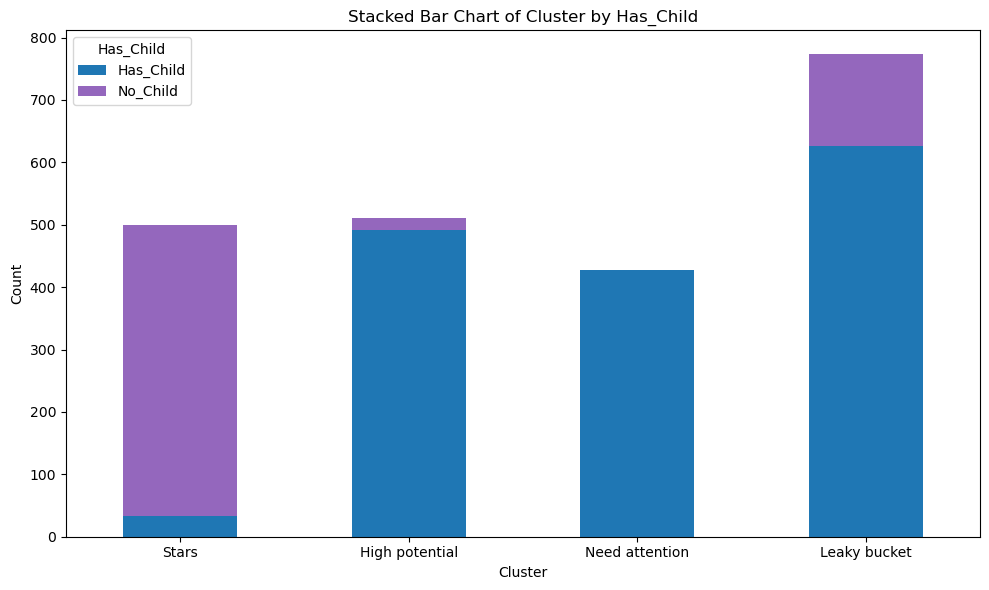

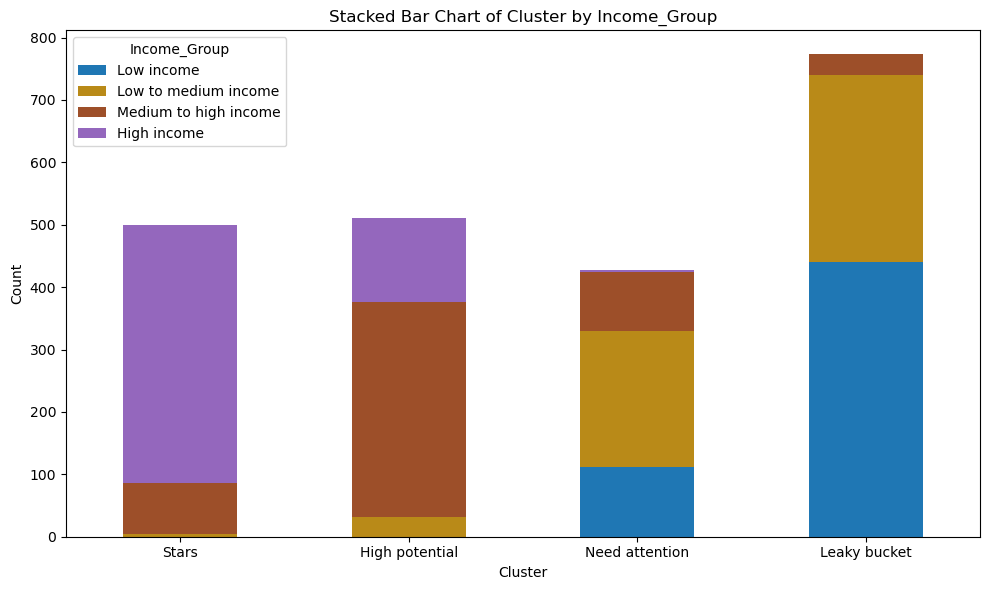

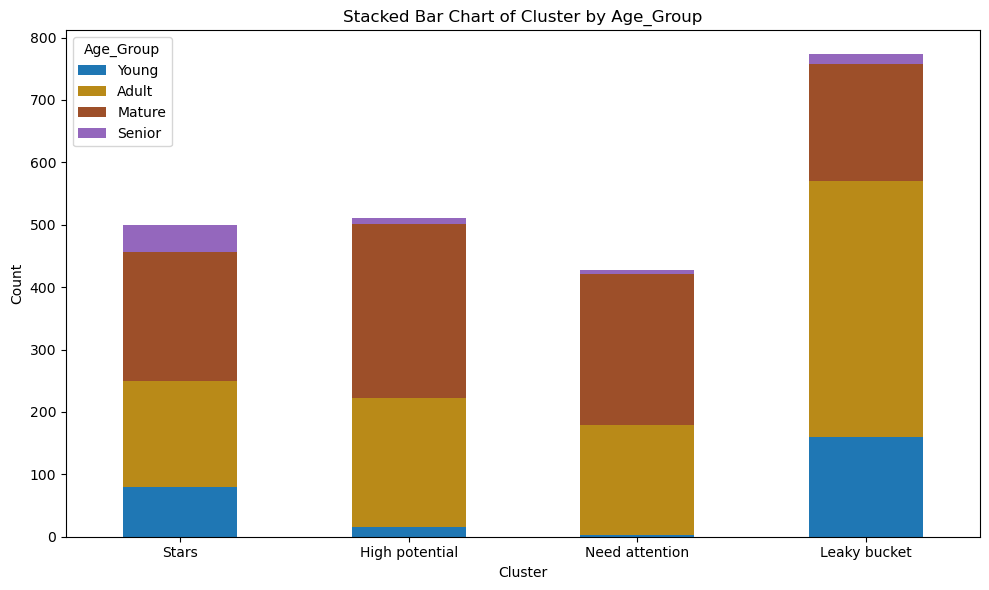

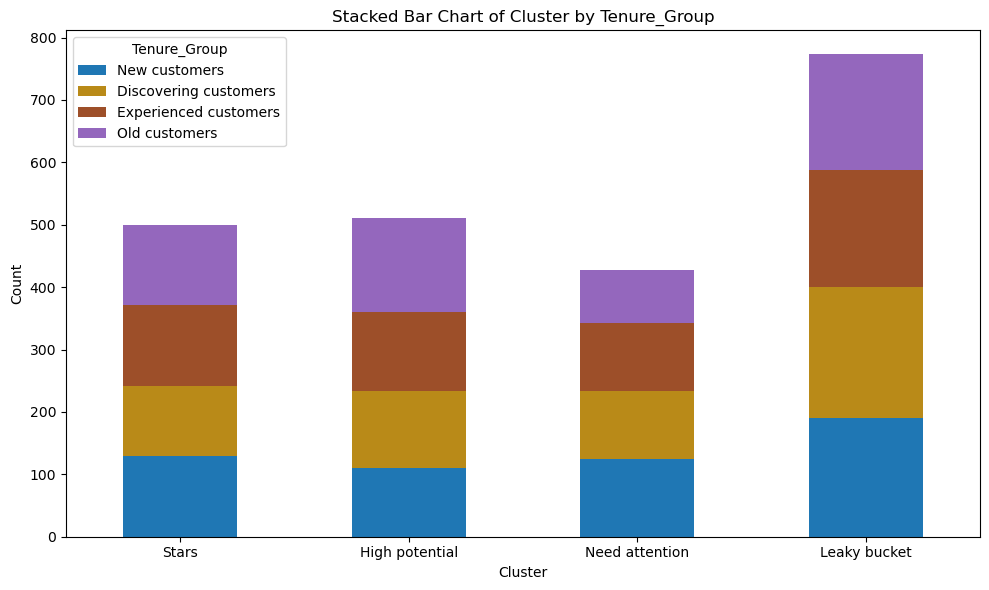

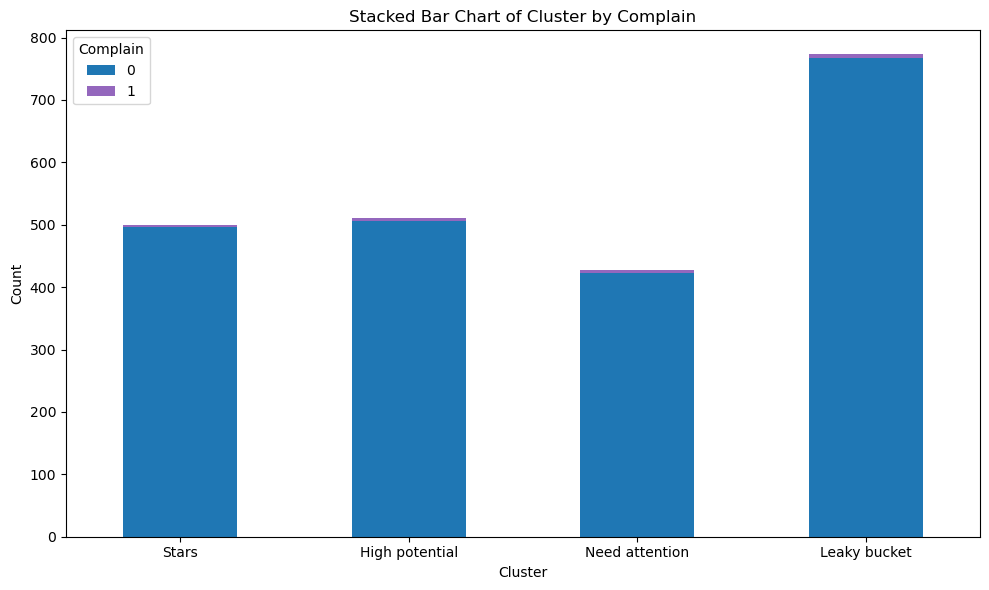

In [58]:
from matplotlib.colors import LinearSegmentedColormap

# Define the color palette
palette = sns.color_palette("tab10", n_colors=5)

# Use the palette to define the custom colormap
cmap = LinearSegmentedColormap.from_list("custom_cmap", palette)

# Custom order for the clusters
cluster_order = ['Stars', 'High potential', 'Need attention', 'Leaky bucket']

# Ensure 'Cluster' column follows the specified order
df_clusters['Cluster'] = pd.Categorical(df_clusters['Cluster'], categories=cluster_order, ordered=True)

# List of categorical columns to plot
categorical_columns = ['Education', 'Marital_Status', 'Children','Kidhome','Teenhome','Has_Child','Income_Group','Age_Group','Tenure_Group','Complain']

for column in categorical_columns:
    # Prepare data
    data = df_clusters.groupby(['Cluster', column]).size().unstack().fillna(0)
    
    # Plot stacked bar chart
    data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap=cmap)
    
    plt.title(f'Stacked Bar Chart of Cluster by {column}')
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    plt.legend(title=column)
    plt.xticks(rotation=0)
    plt.tight_layout()  # Adjust layout to fit labels
    plt.show()

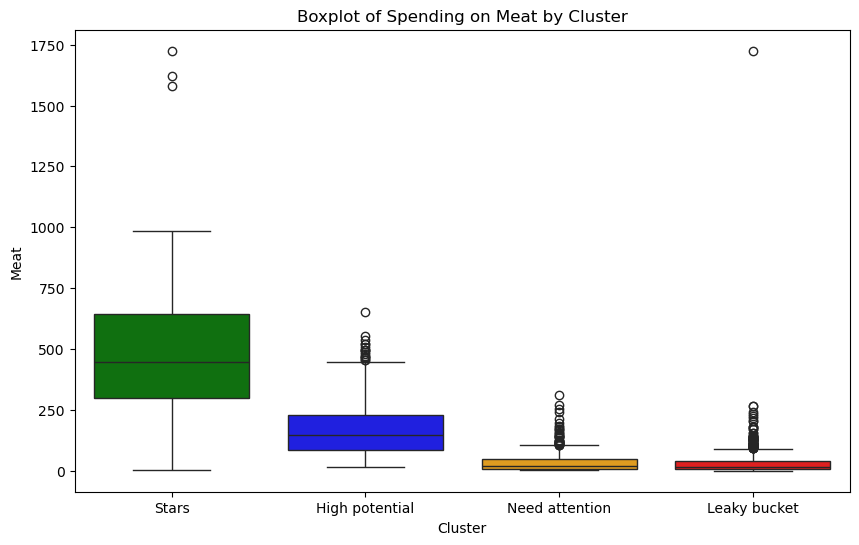

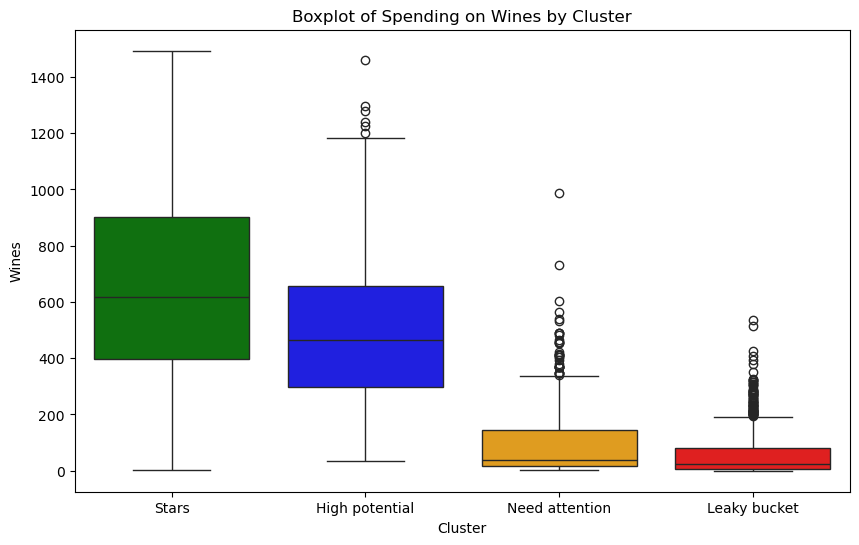

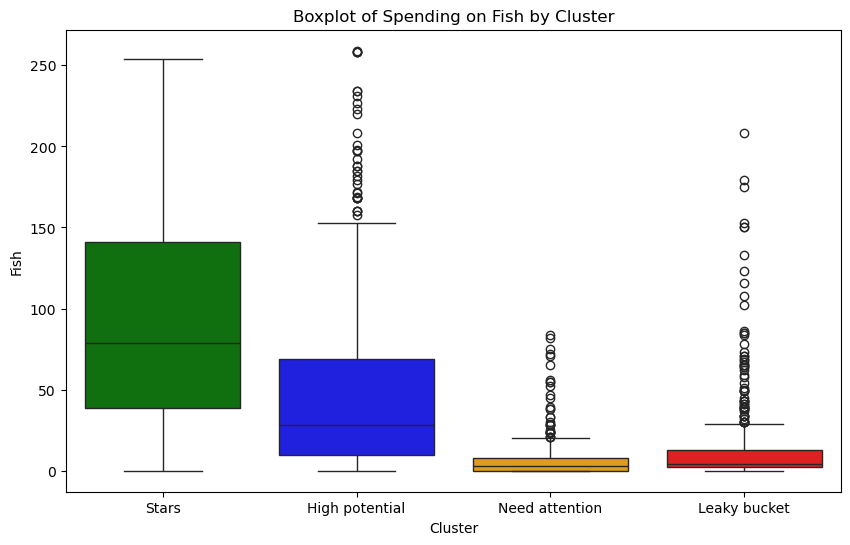

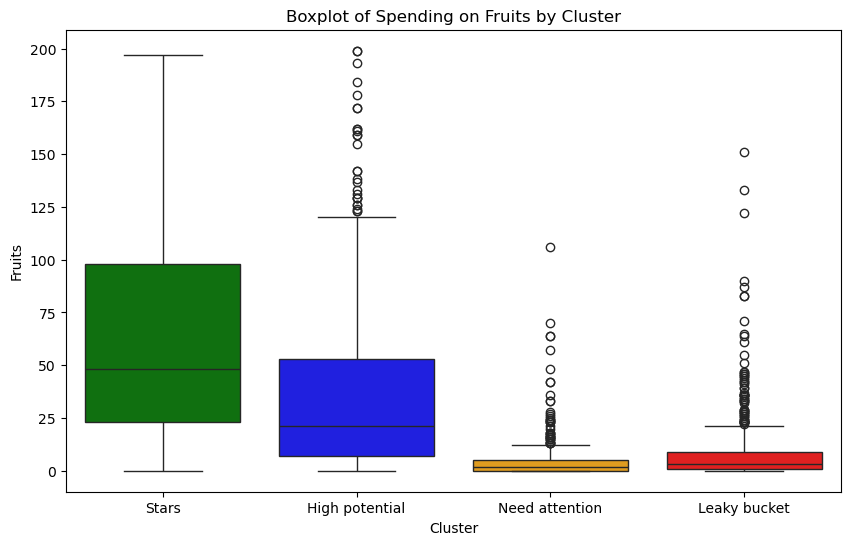

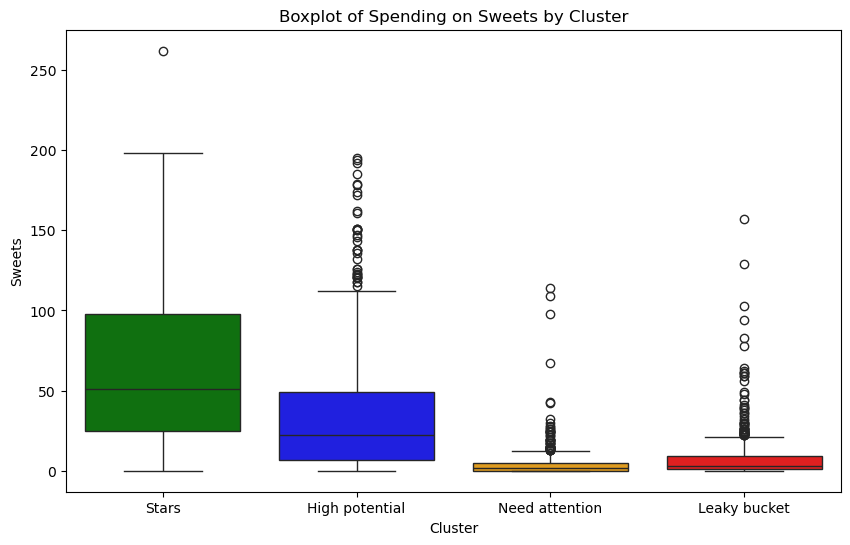

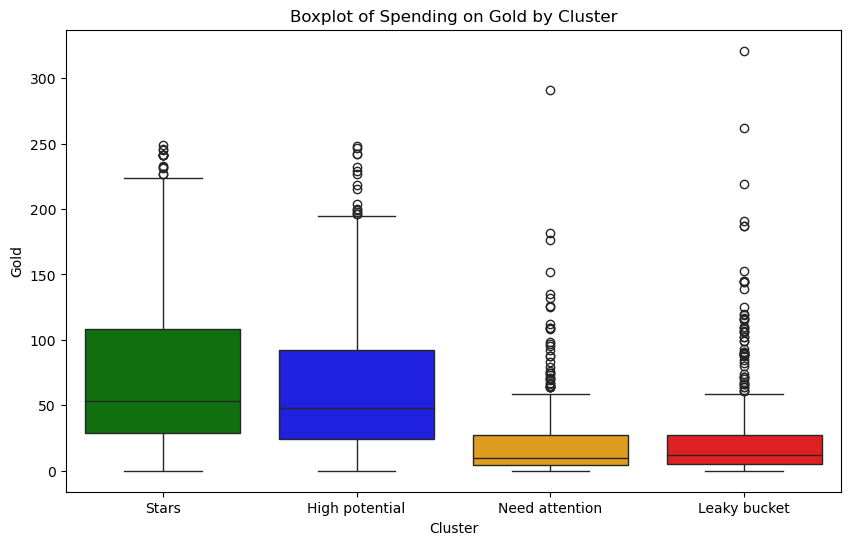

In [59]:
# Visualize the spending on each products by Cluster
columns_to_plot = ['Meat', 'Wines', 'Fish', 'Fruits', 'Sweets', 'Gold'] 

custom_palette = {'Stars':'green', 'Leaky bucket':'red', 'High potential':'blue', 'Need attention':'orange'}

# Plot boxplots for each numerical column
for column in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cluster', y=column, data=df_clusters, order=['Stars','High potential','Need attention','Leaky bucket'], palette=custom_palette)  # Adjust palette as needed
    plt.title(f'Boxplot of Spending on {column} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(column)
    plt.show()

# Clusters Conclusions

**Stars (Cluster 0):**
* Highest income (78k), highest spending (1430) and high purchasing frequency
* More than 90% has no child, less than 10% has one child
* More than 60% has a partner
* Mainly graduate or postgraduate
* Occasionally accept promotions
* Show lowest number of web visits
* Span all ages
* High consumers for meat, wines, fish and sweets

**High Potential (Cluster 2):**
* Majority are medium income (63k), some are high income, few below medium income
* Moderate spending (860) but highest purchasing frequency
* Majority have a parnter
* More than 90% has one child, small portion has two children, very few has no child
* Majority are mature and adult, very few young or senior people
* Mainly graduate or postgraduate
* Rarely accept promotions

**Need attention (Cluster 3):**
* Medium income (42k) and low spending (170)
* Majority have two children, small portion have three children
* Majority are adult and mature
* Majority have a partner
* Low purchasing frequency
* Occasionally made some purchases with a discount
* Do not accept promotions

**Leaky bucket (Cluster 1):**
* Low income (33k) and low spending (140)
* Majority have one child, some have no child
* Have relatively larger portions of adult and young people
* Majority have a partner
* Low purchasing frequency
* Do not accept promotions